# Badanie korelacji między panelami PV i drzewami

In [495]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import statsmodels.api as sm

## Wczytanie danych

In [496]:
pv_df = pd.read_csv('pv_results.csv', header= None, names=['image', 'pv_area_share'])
tree_df = pd.read_csv('tree_results.csv')
pv_df.head()

,image,pv_area_share
0,/users/project1/pt01299/divided_images_jpg/201...,0.010391
1,/users/project1/pt01299/divided_images_jpg/201...,0.001514
2,/users/project1/pt01299/divided_images_jpg/201...,0.001260
3,/users/project1/pt01299/divided_images_jpg/201...,0.001348
4,/users/project1/pt01299/divided_images_jpg/201...,0.000889


In [497]:
pv_df['year'] = pv_df['image'].str.extract(r'/(2019|202[0-4])')
pv_df['year'] = pv_df['year'].astype(int)

pv_df['id'] = pv_df['image'].str.split('/').str[-1]
pv_df['id'] = pv_df['id'].str.replace(r'(2019|202[0-4])_', '', regex=True).str.replace('.jpg', '', regex=False)
pv_df.drop('image', axis=1,  inplace=True)
pv_df.head()

,pv_area_share,year,id
0,0.010391,2019,73213_897606_N-34-62-A-a-2-2_tile_r01_c01
1,0.001514,2019,73213_897606_N-34-62-A-a-2-2_tile_r01_c19
2,0.001260,2019,73213_897606_N-34-62-A-a-2-2_tile_r02_c04
3,0.001348,2019,73213_897606_N-34-62-A-a-2-2_tile_r02_c12
4,0.000889,2019,73213_897606_N-34-62-A-a-2-2_tile_r02_c13


In [498]:
tree_df.head()

,image,tree_area_share,tree_area_percent
0,2024_81010_1322851_N-34-50-C-c-1-2_tile_r139_c...,1.000000,100.000000
1,2024_81010_1322841_N-34-50-A-c-3-1_tile_r130_c...,0.583594,58.359375
2,2021_75094_1042280_N-34-49-B-d-4-4_tile_r23_c0...,1.000000,100.000000
3,2022_76176_1074798_N-34-50-C-d-1-4_tile_r103_c...,0.000000,0.000000
4,2021_74865_1014748_N-34-50-C-c-1-1_tile_r74_c1...,0.285625,28.562500


In [499]:
tree_df['year'] = tree_df['image'].str.extract(r'^(2019|202[0-4])')
tree_df['year'] = tree_df['year'].astype(int)

tree_df['id'] = tree_df['image'].str.replace(r'^(2019|202[0-4])_', '', regex=True).str.replace('.jpg', '', regex=False)
tree_df.drop(['image','tree_area_percent'], axis=1,  inplace=True)

tree_df.head()

,tree_area_share,year,id
0,1.000000,2024,81010_1322851_N-34-50-C-c-1-2_tile_r139_c119
1,0.583594,2024,81010_1322841_N-34-50-A-c-3-1_tile_r130_c103
2,1.000000,2021,75094_1042280_N-34-49-B-d-4-4_tile_r23_c09
3,0.000000,2022,76176_1074798_N-34-50-C-d-1-4_tile_r103_c28
4,0.285625,2021,74865_1014748_N-34-50-C-c-1-1_tile_r74_c16


## Czyszczenie i transformacja danych

In [500]:
tree_df = tree_df.dropna(subset=['id', 'year', 'tree_area_share'])
pv_df = pv_df.dropna(subset=['id', 'year', 'pv_area_share'])
tree_df = tree_df[(tree_df['tree_area_share'] >= 0) & (tree_df['tree_area_share'] <= 1)]
pv_df = pv_df[(pv_df['pv_area_share'] >= 0) & (pv_df['pv_area_share'] <= 1)]

In [501]:
df_merged = pd.merge(
    tree_df,
    pv_df,
    on=['id', 'year'],
    how='outer'
)

In [502]:
df_merged.isna().sum()

tree_area_share        805
year                     0
id                       0
pv_area_share      2830941
dtype: int64

In [503]:
df_merged['pv_area_share'] = df_merged['pv_area_share'].fillna(0)

In [504]:
df_merged['id'] = df_merged['id'].str.extract(r'(N-\d+-\d+-[A-Z]-[a-z]-\d-\d_tile_r+\d+_c+\d+)')

In [505]:
df_merged = df_merged.sort_values(['id', 'year'])
df_merged.head()

,tree_area_share,year,id,pv_area_share
6240,0.0,2019,N-34-49-B-d-2-4_tile_r01_c01,0.000000
72540,0.0,2020,N-34-49-B-d-2-4_tile_r01_c01,0.003906
78000,0.0,2021,N-34-49-B-d-2-4_tile_r01_c01,0.000000
1012400,0.0,2021,N-34-49-B-d-2-4_tile_r01_c01,0.000000
1034240,0.0,2021,N-34-49-B-d-2-4_tile_r01_c01,0.000000


In [506]:
df_merged.isna().sum()

tree_area_share      805
year                   0
id                 20400
pv_area_share          0
dtype: int64

In [507]:
df_merged['year'].value_counts().sort_index()

year
2019      39000
2020      39000
2021    1012400
2022     954800
2023      78805
2024     934400
Name: count, dtype: int64

In [508]:
df_agg = (
    df_merged
    .groupby(['id', 'year'], as_index=False)
    .agg(
        tree_area_share=('tree_area_share', 'mean'),
        pv_area_share=('pv_area_share', 'mean')
    )
)

In [509]:
df_agg['year'].value_counts().sort_index()

year
2019     39000
2020     39000
2021    934400
2022    934400
2023     39000
2024    934400
Name: count, dtype: int64

In [510]:
df_agg.isna().sum()

id                 0
year               0
tree_area_share    0
pv_area_share      0
dtype: int64

In [511]:
df_agg.groupby('id')['year'].nunique().describe()

count    934400.000000
mean          3.125214
std           0.599970
min           3.000000
25%           3.000000
50%           3.000000
75%           3.000000
max           6.000000
Name: year, dtype: float64

In [512]:
df_full = df_agg.copy()
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2920200 entries, 0 to 2920199
Data columns (total 4 columns):
 #   Column           Dtype  
---  ------           -----  
 0   id               object 
 1   year             int64  
 2   tree_area_share  float64
 3   pv_area_share    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 89.1+ MB


In [513]:
df_full['area_id'] = df_full['id'].str.extract(r'(N-\d+-\d+-[A-Z]-[a-z]-\d-\d)')
df_full.head()

,id,year,tree_area_share,pv_area_share,area_id
0,N-34-49-B-d-2-4_tile_r01_c01,2019,0.000000,0.000000,N-34-49-B-d-2-4
1,N-34-49-B-d-2-4_tile_r01_c01,2020,0.000000,0.003906,N-34-49-B-d-2-4
2,N-34-49-B-d-2-4_tile_r01_c01,2021,0.000000,0.000000,N-34-49-B-d-2-4
3,N-34-49-B-d-2-4_tile_r01_c01,2022,0.000000,0.000000,N-34-49-B-d-2-4
4,N-34-49-B-d-2-4_tile_r01_c01,2023,0.002812,0.000000,N-34-49-B-d-2-4


In [514]:
df_full[['tree_area_share', 'pv_area_share']].describe()

,tree_area_share,pv_area_share
count,2.920200e+06,2.920200e+06
mean,4.529130e-01,4.989489e-03
std,4.230187e-01,4.498491e-02
min,0.000000e+00,0.000000e+00
25%,8.593750e-03,0.000000e+00
50%,3.225000e-01,0.000000e+00
75%,9.812500e-01,0.000000e+00
max,1.000000e+00,1.000000e+00


In [515]:
df_full['year'].value_counts().sort_index()

year
2019     39000
2020     39000
2021    934400
2022    934400
2023     39000
2024    934400
Name: count, dtype: int64

In [516]:
df_full['pixel_size'] = np.where(
    df_full['year'].isin([2019, 2020, 2023]),
    0.25,
    0.5
)
df_full['pixel_area'] = df_full['pixel_size'] ** 2

In [517]:
df_full[['year', 'pixel_size', 'pixel_area']].drop_duplicates().sort_values('year')

,year,pixel_size,pixel_area
0,2019,0.25,0.0625
1,2020,0.25,0.0625
2,2021,0.50,0.2500
3,2022,0.50,0.2500
4,2023,0.25,0.0625
5,2024,0.50,0.2500


In [518]:
df = (
    df_full
    .groupby(['area_id', 'year'])
    .apply(lambda x: pd.Series({
        'tree_area_share': (x['tree_area_share'] * x['pixel_area']).sum()
                            / x['pixel_area'].sum(),
        'pv_area_share': (x['pv_area_share'] * x['pixel_area']).sum()
                          / x['pixel_area'].sum()
    }))
    .reset_index()
)
df['year'].value_counts().sort_index()

C:\Users\epaw0\AppData\Local\Temp\ipykernel_12208\3708435897.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


year
2019    50
2020    50
2021    50
2022    50
2023    50
2024    50
Name: count, dtype: int64

In [519]:
df_area = df.sort_values(['area_id', 'year'])

In [520]:
df.groupby('area_id')['year'].nunique().describe()

count    50.0
mean      6.0
std       0.0
min       6.0
25%       6.0
50%       6.0
75%       6.0
max       6.0
Name: year, dtype: float64

In [521]:
df.head(6)

,area_id,year,tree_area_share,pv_area_share
0,N-34-49-B-d-2-4,2019,0.195153,0.004866
1,N-34-49-B-d-2-4,2020,0.129330,0.002068
2,N-34-49-B-d-2-4,2021,0.162871,0.003579
3,N-34-49-B-d-2-4,2022,0.188653,0.007432
4,N-34-49-B-d-2-4,2023,0.118492,0.004649
5,N-34-49-B-d-2-4,2024,0.237624,0.005454


In [522]:
df['delta_tree'] = df.groupby('area_id')['tree_area_share'].diff()
df['delta_pv'] = df.groupby('area_id')['pv_area_share'].diff()

In [523]:
df['pv_appeared'] = (
    (df['pv_area_share'] > 0)
    & (df.groupby('area_id')['pv_area_share'].shift(1).fillna(0) == 0)
)

In [524]:
df['post_PV'] = df.groupby('area_id')['pv_appeared'].cumsum() > 0
df['have_PV'] = df.groupby('area_id')['pv_area_share'].transform('max') > 0

In [525]:
df.head(6)

,area_id,year,tree_area_share,pv_area_share,delta_tree,delta_pv,pv_appeared,post_PV,have_PV
0,N-34-49-B-d-2-4,2019,0.195153,0.004866,NaN,NaN,True,True,True
1,N-34-49-B-d-2-4,2020,0.129330,0.002068,-0.065823,-0.002798,False,True,True
2,N-34-49-B-d-2-4,2021,0.162871,0.003579,0.033541,0.001511,False,True,True
3,N-34-49-B-d-2-4,2022,0.188653,0.007432,0.025782,0.003853,False,True,True
4,N-34-49-B-d-2-4,2023,0.118492,0.004649,-0.070160,-0.002783,False,True,True
5,N-34-49-B-d-2-4,2024,0.237624,0.005454,0.119132,0.000805,False,True,True


## Analiza korelacji

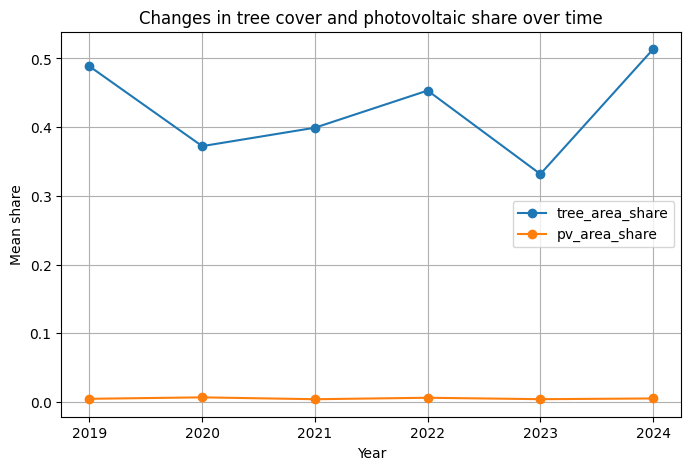

In [526]:
df.groupby('year')[['tree_area_share', 'pv_area_share']].mean().plot(figsize=(8,5),
    title="Changes in tree cover and photovoltaic share over time",marker="o")
plt.xlabel("Year")
plt.ylabel("Mean share")
plt.grid(True)
plt.show()

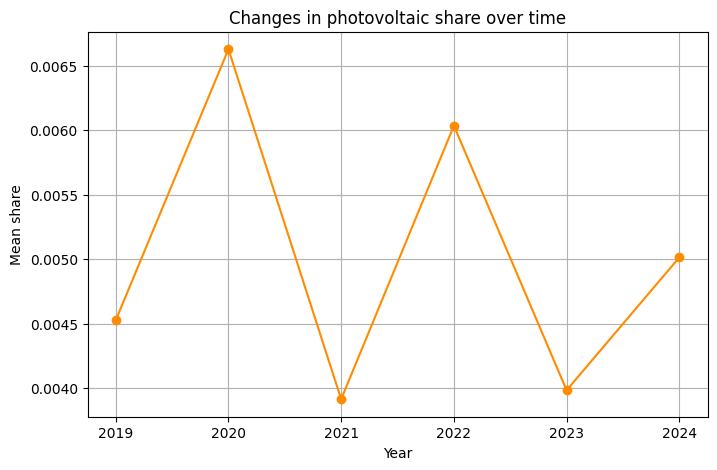

In [527]:
df.groupby('year')['pv_area_share'].mean().plot(figsize=(8,5),
    title="Changes in photovoltaic share over time", marker="o",color='darkorange')
plt.xlabel("Year")
plt.ylabel("Mean share")
plt.grid(True)
plt.show()

Średni udział instalacji fotowoltaicznych utrzymuje się na niskim poziomie we wszystkich latach, nastomiast zadrzewienie wykazuje większą zmienność z roku na rok. Wykresy nie wskazują na silną ani spójną zależność między tymi dwiema zmiennymi

#### Before-after

In [528]:
before_mean = df.loc[df['have_PV'] & (~df['post_PV']), 'delta_tree'].mean()
after_mean  = df.loc[df['have_PV'] & (df['post_PV']),  'delta_tree'].mean()

print('Średnia zmiana drzew BEFORE:', before_mean)
print('Średnia zmiana drzew AFTER :', after_mean)

Średnia zmiana drzew BEFORE: nan
Średnia zmiana drzew AFTER : 0.004973870906624766


W większości analizowanych obszarów panele istnieją już w pierwszym roku danych, więc analiza before-after/DiD nie jest możliwa.

#### Analiza zależności zmian

Czy w latach, gdy bardziej przybywa paneli, drzewa zwykle bardziej znikają?

In [529]:
df[['delta_tree', 'delta_pv']].corr()

,delta_tree,delta_pv
delta_tree,1.000000,-0.061003
delta_pv,-0.061003,1.000000


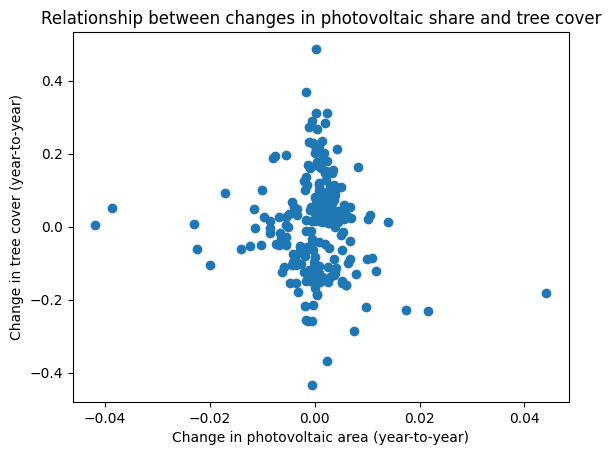

In [530]:
plt.scatter(df['delta_pv'], df['delta_tree'])
plt.xlabel('Change in photovoltaic area (year-to-year)')
plt.ylabel('Change in tree cover (year-to-year)')
plt.title('Relationship between changes in photovoltaic share and tree cover')
plt.show()

Wynik -0.06 oznacza, że gdy PV rośnie, zadrzewienie lekko maleje. Jest to jednak mała wartość (bliska 0), co wskazuje na bardzo małą zależność (prawie brak).

In [531]:
mask = df[["delta_pv", "delta_tree"]].dropna().index
r, p = pearsonr(df.loc[mask, "delta_pv"], df.loc[mask, "delta_tree"])
r, p

(np.float64(-0.06100282334230123), np.float64(0.3367531039278936))

Wartość p>0.05 oznacza, że wynik nie jest istotny statystycznie. Nie stwierdzono istotnej statystycznie zależności pomiędzy zmianami udziału instalacji fotowoltaicznych a zmianami zadrzewienia.

In [532]:
X = df.loc[mask, "delta_pv"]
y = df.loc[mask, "delta_tree"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             delta_tree   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9263
Date:                Tue, 30 Dec 2025   Prob (F-statistic):              0.337
Time:                        02:26:35   Log-Likelihood:                 155.28
No. Observations:                 250   AIC:                            -306.6
Df Residuals:                     248   BIC:                            -299.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0051      0.008      0.616      0.5

Na podstawie wyników widać, że nie ma statystycznie istotnego związku między zmianą PV a zmianą zadrzewienia. Mimo, że coef = -1.1394 (większy wzrost PV wiąże się z mniejszym przyrostem drzew) to przez p = 0.337 wynik nie można uznać na istotny totny statystycznie. Poandto model wyjaśnia tylko 0.4% zmienności w danych.

W celu sprawdzenia, czy budowanie instalacji fotowoltaicznych może wpływać na zmiany zadrzewienia, oprócz przeprowadzenia analizy korelacji pomiędzy rocznymi zmianami obu zmiennych, dodatkowo uwzględniono również jednoroczne przesunięcie czasowe (lag). Takie podejście pozwala sprawdzić, czy wzrost powierzchni instalacji fotowoltaicznych w danym roku wiąże się ze zmianami zadrzewienia w roku kolejnym (często ich wpływ może ujawnić się z opóźnieniem).

In [533]:
df['delta_pv_lag1'] = df.groupby('area_id')['delta_pv'].shift(1)
df[['delta_tree', 'delta_pv_lag1']].corr()

,delta_tree,delta_pv_lag1
delta_tree,1.000000,-0.144787
delta_pv_lag1,-0.144787,1.000000


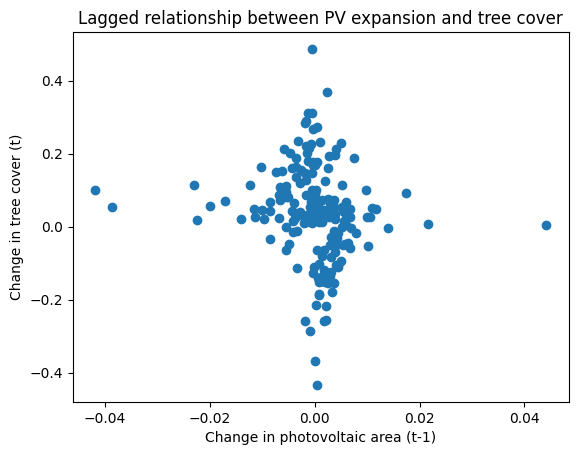

In [534]:
plt.scatter(df['delta_pv_lag1'], df['delta_tree'])
plt.xlabel('Change in photovoltaic area (t-1)')
plt.ylabel('Change in tree cover (t)')
plt.title('Lagged relationship between PV expansion and tree cover')
plt.show()

Wartość współczynnika korelacji (-0.144787) wskazuje na słabą ujemną zależność między badanymi zmiennymi. Oznacza to, że większy wzrost powierzchni instalacji PV w poprzednim roku może wiązać się z nieznacznie mniejszym przyrostem zadrzewienia w kolejnym roku. Słabą zależność potwierdza również wykres (duża zmienność oraz brak wyraźnego trendu liniowego).

In [535]:
mask = df[["delta_tree", "delta_pv_lag1"]].dropna().index
r_lag, p_lag = pearsonr(
    df.loc[mask, "delta_tree"],
    df.loc[mask, "delta_pv_lag1"]
)

r_lag, p_lag

(np.float64(-0.14478662318383986), np.float64(0.04080078696622541))

Występuje słaba, ale statystycznie istotna (p<0.05) ujemna korelacja pomiędzy zmianami powierzchni PV a zmianami zadrzewienia.

In [536]:
X = df['delta_pv_lag1']
y = df['delta_tree']

mask = X.notna() & y.notna()

X = sm.add_constant(X[mask])
y = y[mask]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             delta_tree   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     4.240
Date:                Tue, 30 Dec 2025   Prob (F-statistic):             0.0408
Time:                        02:26:35   Log-Likelihood:                 131.29
No. Observations:                 200   AIC:                            -258.6
Df Residuals:                     198   BIC:                            -252.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0349      0.009      3.917

Na podstawie liniowego model regresji z jednorocznym opóźnieniem zmiennej, widać słabą, ale statystycznie istotną ujemną zależność pomiędzy przyrostem powierzchni instalacji PV w roku poprzednim a zmianą zadrzewienia w roku następnym. Wskazuje na to coef =-2.4042 oraz p=0.041. Niski współczynnik determinacji (0.021) sugeruje, że zmiany zadrzewienia są w niewielkim stopniu wyjaśniane przez zmienną PV i mogą mieć na nie wpływ inne czynniki.

Uzyskane wyniki wskazują na istnienie słabej, lecz statystycznie istotnej zależności pomiędzy budowaniem instalacji fotowoltaicznych a zmianami zadrzewienia. Siła tej zależności jest niewielka, jej kierunek jest zgodny z hipotezą o potencjalnym konflikcie pomiędzy rozwojem PV a terenami zielonymi.